# LECTURE 1 LIVE CODING


In [1]:
# Import libraries (Python equivalent of R packages like dplyr, ggplot2)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix

In [2]:

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print("Rows in dataset:", len(raw_data))

Rows in dataset: 7214


In [3]:

print(raw_data.head())

   id                name   first         last compas_screening_date   sex  \
0   1    miguel hernandez  miguel    hernandez            2013-08-14  Male   
1   3         kevon dixon   kevon        dixon            2013-01-27  Male   
2   4            ed philo      ed        philo            2013-04-14  Male   
3   5         marcu brown   marcu        brown            2013-01-13  Male   
4   6  bouthy pierrelouis  bouthy  pierrelouis            2013-03-26  Male   

          dob  age          age_cat              race  ...  v_decile_score  \
0  1947-04-18   69  Greater than 45             Other  ...               1   
1  1982-01-22   34          25 - 45  African-American  ...               1   
2  1991-05-14   24     Less than 25  African-American  ...               3   
3  1993-01-21   23     Less than 25  African-American  ...               6   
4  1973-01-22   43          25 - 45             Other  ...               1   

   v_score_text  v_screening_date  in_custody  out_custody  pr

In [4]:
# Data Preprocessing and Feature Engineering (R → Python Translation)

# This step translates the R `dplyr` workflow into Python using pandas.
# Relevant columns are selected using DataFrame indexing, equivalent to `select()` in R.


df = raw_data[[
    "age",
    "c_charge_degree",
    "race",
    "age_cat",
    "score_text",
    "sex",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score",
    "is_recid",
    "two_year_recid",
    "c_jail_in",
    "c_jail_out"
]].copy()

#Filtering conditions are applied using boolean indexing, replicating multiple `filter()` steps.
df = df[(df["days_b_screening_arrest"] >= -30) &
        (df["days_b_screening_arrest"] <= 30)]

df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]


# Datetime variables are converted using `pd.to_datetime()`, matching R’s `as.POSIXct()`.
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"])
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"])



# New variables are created to mirror R’s `mutate()`:
# `crime_factor` replicates factor conversion of charge degree
# `age_factor` is created as a categorical variable with an ordered reference level
# `race_factor` and `gender_factor` replicate categorical transformations
# `score_factor` converts score_text into a binary categorical outcome (LowScore vs HighScore)
df["crime_factor"] = df["c_charge_degree"]

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"]
)

df["race_factor"] = pd.Categorical(df["race"])

df["gender_factor"] = df["sex"].replace({
    "Male": "Male",
    "Female": "Female"
})

df["score_factor"] = np.where(df["score_text"] == "Low",
                              "LowScore", "HighScore")


# The final row count is printed to verify that preprocessing matches the R output

print("Filtered rows:", len(df))

Filtered rows: 6172


In [5]:
df.head()

#This step replicates the `head(df)` function from R using `df.head()` in Python.

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore


In [6]:
df.info()
#This step uses `df.info()` in Python to replicate the functionality of `glimpse(df)`

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   object        
 2   race                     6172 non-null   object        
 3   age_cat                  6172 non-null   object        
 4   score_text               6172 non-null   object        
 5   sex                      6172 non-null   object        
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   int64         
 10  two_year_recid           6172 non-null   int64         
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

In [7]:
# Length of Stay and Correlation
#This step computes `length_of_stay` by taking the difference between `c_jail_out` and `c_jail_in` in days, replicating the R date subtraction.
# The correlation with `decile_score` is then calculated using `.corr()`, which is the Python equivalent of R’s `cor()`.
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

correlation = df["length_of_stay"].corr(df["decile_score"])
print("Correlation:", correlation)

Correlation: 0.20747808478031807


age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64
sex
Male      4997
Female    1175
Name: count, dtype: int64


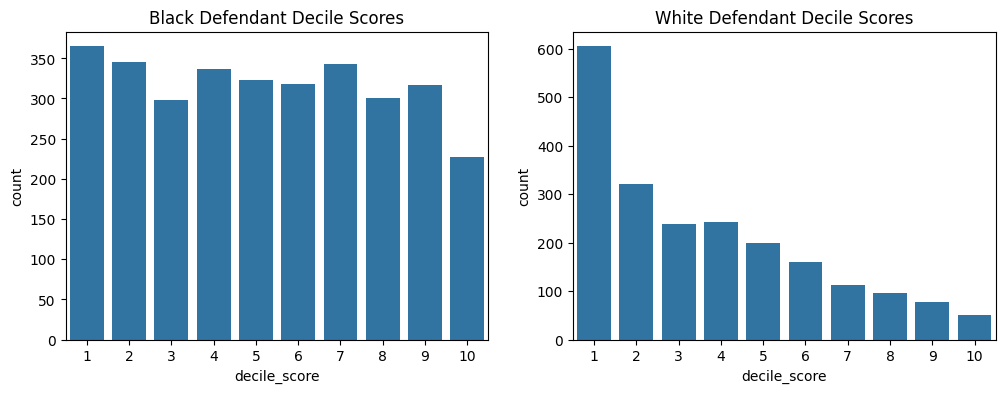

In [8]:

# Demographic Summaries and Visualization
#This step reproduces the R summary outputs using `value_counts()` in Python to display the distribution of age, race, and sex.
#Additionally, count plots are created using `seaborn` to visualize the distribution of decile scores by race.
#This corresponds to R’s use of summary tables and `ggplot2` visualizations, allowing for comparison of score distributions across demographic groups.
print(df["age_cat"].value_counts())
print(df["race"].value_counts())
print(df["sex"].value_counts())

fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.countplot(data=df[df["race"]=="African-American"],
              x="decile_score",
              ax=axes[0])

axes[0].set_title("Black Defendant Decile Scores")

sns.countplot(data=df[df["race"]=="Caucasian"],
              x="decile_score",
              ax=axes[1])

axes[1].set_title("White Defendant Decile Scores")

plt.show()

In [9]:
# Logistic Regression and Evaluation
#Predicted probabilities are converted into binary class predictions using a 0.5 threshold.

df["score_binary"] = np.where(df["score_factor"] == "HighScore", 1, 0)

formula = """
score_binary ~ C(gender_factor, Treatment(reference='Male'))
             + C(age_factor, Treatment(reference='25 - 45'))
             + C(race_factor, Treatment(reference='Caucasian'))
             + priors_count
             + C(crime_factor)
             + two_year_recid
"""

#A binary target variable is created from `score_factor` (HighScore vs LowScore), and categorical predictors are specified with `C()` while explicitly setting reference categories to match the R model.


model = smf.logit(formula, data=df).fit()
print(model.summary())

df["pred_prob"] = model.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, 1, 0)
#Predicted probabilities are converted into binary class predictions using a 0.5 threshold.

# A confusion matrix and performance metrics are then computed to evaluate how well the model predicts COMPAS score classification.
cm = confusion_matrix(df["score_binary"], df["pred_class"])

TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / cm.sum()
precision = TP / (TP + FP)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("FPR:", fpr)
print("FNR:", fnr)


Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        14:12:47   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------

In [10]:
# LOGIT Odds Ratio Interpretation
#This step translates the R calculation of predicted probabilities into Python to interpret the logistic regression coefficient.
#The baseline probability (`control`) is computed from the intercept, and the effect of the race coefficient is applied using the logistic transformation.
#The resulting value represents the odds ratio, showing how much more likely one group is to receive a higher score compared to the reference group, holding other variables constant.
import numpy as np

control = np.exp(-1.5255) / (1 + np.exp(-1.5255))

result = np.exp(0.4772) / (1 - control + (control * np.exp(0.4772)))

print(result)

1.452825407001621


In [11]:
# Gender Effect Interpretation
#This step applies the logistic transformation to the gender coefficient to compute the odds ratio.
# Using the baseline probability (`control`), the result quantifies how much more likely women are to receive a higher score compared to men, holding other variables constant.

result = np.exp(0.2213) / (1 - control + (control * np.exp(0.2213)))

print(result)

1.1948243807769987


In [12]:
# Age Effect Interpretation
#This step computes the odds ratio for individuals under 25 using the logistic transformation.
#Based on the model coefficient, the result indicates that individuals under 25 are significantly more likely to receive a higher score compared to the reference group (ages 25–45), holding other variables constant.

result = np.exp(1.3084) / (1 - control + (control * np.exp(1.3084)))

print(result)


2.496107351371129


In [13]:
# Predictions (equivalent to R mutate with predict + ifelse)

df["pred_prob"] = model.predict(df)

df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")

In [14]:
# Overall Confusion Matrix and Model Evaluation

from sklearn.metrics import confusion_matrix

print("Overall Confusion Matrix")

cm = confusion_matrix(df["two_year_recid"], df["pred_class"] == "Recid")

print(cm)


TN, FP, FN, TP = cm.ravel()
n = cm.sum()

# The confusion matrix is  decomposed into:
# True Negatives (TN)
# False Positives (FP)
# False Negatives (FN)
# True Positives (TP)
accuracy = (TP + TN) / n
precision = TP / (TP + FP)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)


# Using these values, key performance metrics are computed:
#  Accuracy: overall correctness of predictions
#  Precision: proportion of predicted positives that are correct
# Recall: proportion of actual positives correctly identified
#  FPR (False Positive Rate): rate of incorrect positive predictions
# FNR (False Negative Rate): rate of missed positive cases

print(f"\nAccuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"FPR      : {fpr:.3f}")
print(f"FNR      : {fnr:.3f}")

Overall Confusion Matrix
[[2653  710]
 [ 945 1864]]

Accuracy : 0.732
Precision: 0.724
Recall   : 0.664
FPR      : 0.211
FNR      : 0.336


In [15]:
print("Confusion Matrix by Race")

results = []

# The dataset is grouped by race, and for each group, actual outcomes and predicted
# classes are converted into binary values (0/1), matching R’s `as.integer()` logic.

for race, g in df.groupby("race"):
    actual = g["two_year_recid"].astype(int)
    pred = (g["pred_class"] == "Recid").astype(int)

    TP = ((pred == 1) & (actual == 1)).sum()
    TN = ((pred == 0) & (actual == 0)).sum()
    FP = ((pred == 1) & (actual == 0)).sum()
    FN = ((pred == 0) & (actual == 1)).sum()
    n = len(g)

    results.append({
        "race": race,
        "n": n,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": round((TP + TN) / n, 3),
        "Precision": round(TP / (TP + FP), 3) if (TP + FP) > 0 else 0,
        "Recall": round(TP / (TP + FN), 3) if (TP + FN) > 0 else 0,
        "FPR": round(FP / (FP + TN), 3) if (FP + TN) > 0 else 0,
        "FNR": round(FN / (FN + TP), 3) if (FN + TP) > 0 else 0
    })

race_metrics = pd.DataFrame(results).sort_values("n", ascending=False)

print(race_metrics)

Confusion Matrix by Race
               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In [16]:
print("FPR and FNR Disparity by Race")


# First, the FPR and FNR values for the Caucasian group are extracted.
ref_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].values[0]
ref_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].values[0]

# Then, a new DataFrame is created with relevant columns.
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# For each race, the differences (delta_FPR and delta_FNR) are computed
# by subtracting the reference group's values, equivalent to R’s `mutate()` logic.


disparity["delta_FPR"] = (disparity["FPR"] - ref_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - ref_fnr).round(3)

print(disparity)

FPR and FNR Disparity by Race
               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


# LECTURE 2 LIVE CODING


In [17]:
#step 0
from sklearn.model_selection import train_test_split

# Define features and target for the split
features = ['gender_factor', 'age_factor', 'race_factor', 'priors_count', 'crime_factor']
target = 'two_year_recid'

X = df[features]
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 5), Test: (1235, 5)


In [18]:

#step1
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define numeric and categorical features
numeric_features = ['priors_count']
category_features = ['gender_factor', 'age_factor', 'race_factor', 'crime_factor']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# Logistic regression (GLM — interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [19]:

#step2
import pandas as pd
from sklearn.metrics import (confusion_matrix,
                             accuracy_score,
                             roc_auc_score)

def group_metrics(pipeline, X, y, group_col="race"): # The default 'race' might not exist in X
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        # Ensure confusion_matrix always returns a 2x2 matrix by specifying labels
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(
                gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) > 0 else 0,
            "FNR": round(fn / (fn + tp), 3) if (fn + tp) > 0 else 0,
            "AUC": round(roc_auc_score(
                gdf["actual"], gdf["pred_prob"]), 3) if len(gdf['actual'].unique()) > 1 else 0,
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)


print(" Logistic Regression ")
# Corrected the group_col to 'race_factor'
print(group_metrics(lr_pipeline, X_test, y_test, group_col="race_factor"))

print("\n Gradient-Boosted Tree ")
# Corrected the group_col to 'race_factor'
print(group_metrics(gbt_pipeline, X_test, y_test, group_col="race_factor"))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.694  0.326  0.288  0.752
2         Caucasian  427     0.663  0.158  0.634  0.669
3          Hispanic   94     0.606  0.082  0.733  0.629
5             Other   65     0.769  0.106  0.556  0.755
1             Asian    7     0.857  0.000  1.000  0.833
4   Native American    1     1.000  0.000  0.000  0.000

 Gradient-Boosted Tree 


/tmp/ipykernel_1735/2359288555.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, gdf in X_.groupby(group_col):
/tmp/ipykernel_1735/2359288555.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, gdf in X_.groupby(group_col):


               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.688  0.276  0.344  0.728
2         Caucasian  427     0.660  0.165  0.627  0.684
3          Hispanic   94     0.660  0.204  0.489  0.621
5             Other   65     0.754  0.128  0.556  0.778
1             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000  0.000  0.000


In [20]:
#step3 LIME explanations: Black vs White defendant
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
X_train_enc = preprocessor.fit_transform(X_train)
explainer = LimeTabularExplainer(
training_data = X_train_enc,
feature_names = (numeric_features +
list(preprocessor.named_transformers_["cat"]
.get_feature_names_out(
category_features))),
class_names = ["No Recid", "Recid"],
mode = "classification",
discretize_continuous= True,
random_state = 42
)
# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_idx = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob").index[len(X_test_copy[X_test_copy["race_factor"] == "African-American"]) // 2]
white_idx = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob").index[len(X_test_copy[X_test_copy["race_factor"] == "Caucasian"]) // 2]

# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx),
("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row = row_enc[0],
        predict_fn= gbt_pipeline["classifier"].predict_proba,
        num_features=6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=baaa531a7cd4279b271cb8d1c349f3feaa37f0f681be0605e34c0d4b15078f36
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime

 LIME: Black defendant 
Predicted probability: 0.487
 age_factor_Less than 25 > 0.00           +0.1941
 age_factor_Greater than 45 <= 0.00       +0.0966
 age_factor_25 - 45 <= 0.00               -0.0449
 crime_factor_F <= 0.00                   -0.0357
 0.00 < crime_factor_M <= 1.00            -0.0207
 0.00 < race_factor_African-American <= 1.00 +0.0190

 LIME: White defendant 
Predicted probability: 0.348
 age_factor_Less than 25 <= 0.00          -0.1932
 race_factor_Asian <= 0.00                +0.1616
 age_factor_Greater than 45 <= 0.00       +0.0954
 -0.48 < priors_count <= 0.16        

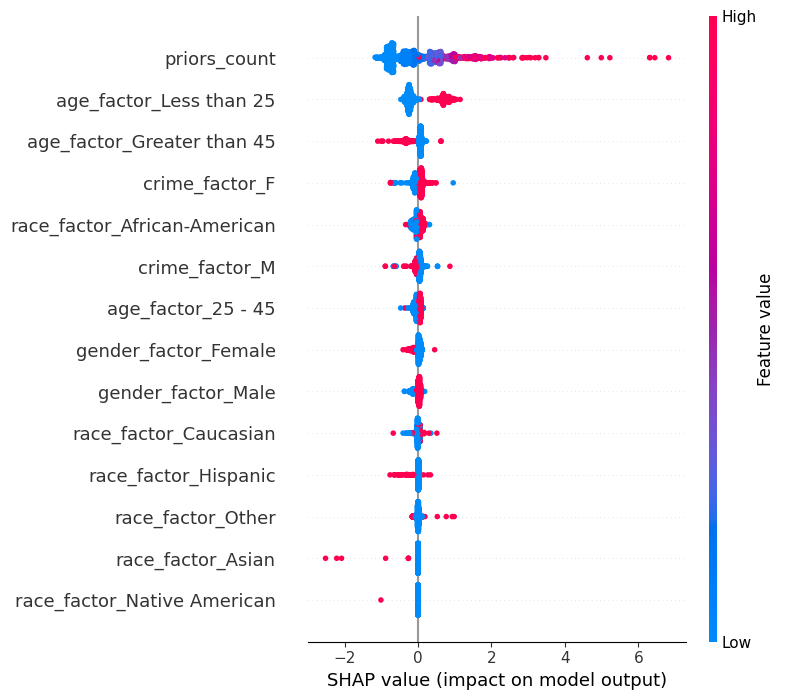

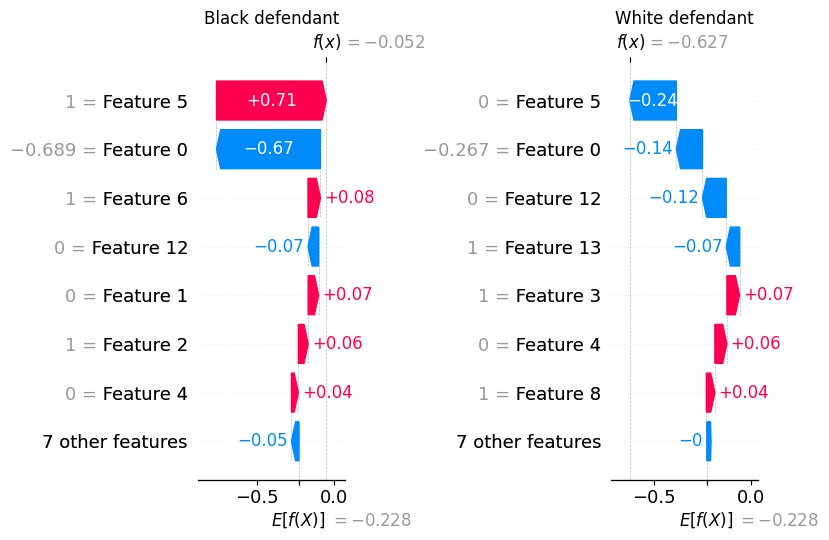

In [21]:
#step 4 SHAP beeswarm and waterfall: Black vs White

!pip install shap
import shap
import matplotlib.pyplot as plt
X_test_enc = preprocessor.transform(X_test)
feat_names = (numeric_features +
list(preprocessor
.named_transformers_["cat"]
.get_feature_names_out(category_features)))
explainer_shap = shap.Explainer(
gbt_pipeline["classifier"],
shap.maskers.Independent(X_test_enc, max_samples=100)
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)
# Global beeswarm
shap.summary_plot(shap_values, X_test_enc,
feature_names=feat_names)
# Waterfall: Black defendant
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
(axes[1], white_loc, "White defendant")
]:
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc],
    max_display=8,
    show=False)
    ax.set_title(label)
plt.tight_layout()
plt.show()

In [22]:
#step5 Counterfactuals with DiCE: Black vs White
!pip install dice-ml
import dice_ml
from dice_ml import Dice
# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
dataframe = pd.concat([X_train, y_train], axis=1),
continuous_features = numeric_features,
outcome_name = target
)
dice_model = dice_ml.Model(
model = gbt_pipeline,
backend = "sklearn",
model_type = "classifier"
)
exp_dice = Dice(dice_data, dice_model, method="random")
for label, idx in [("Black defendant", black_idx),
("White defendant", white_idx)]:
    query = X_test.loc[[idx]]
    cf = exp_dice.generate_counterfactuals(
    query,
    total_CFs = 3,
    desired_class = "opposite",
    permitted_range = {"priors_count": [0, 38]},
    features_to_vary = ["priors_count", "age_factor", "crime_factor"]
    )
    print(f"\n DiCE counterfactuals: {label} ")
    cf.visualize_as_dataframe(show_only_changes=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 21.4 MB/s eta 0:00:00


100%|██████████| 1/1 [00:00<00:00,  2.59it/s]


 DiCE counterfactuals: Black defendant 
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,Male,Less than 25,African-American,0,M,0



Diverse Counterfactual set (new outcome: 1)


...

100%|██████████| 1/1 [00:00<00:00,  4.10it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,Male,25 - 45,Caucasian,2,M,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,-,Greater than 45,-,9,-,1
1,-,Less than 25,-,-,F,1
2,-,-,-,35,-,1


 96%|=================== | 1191/1235 [00:13<00:00]       

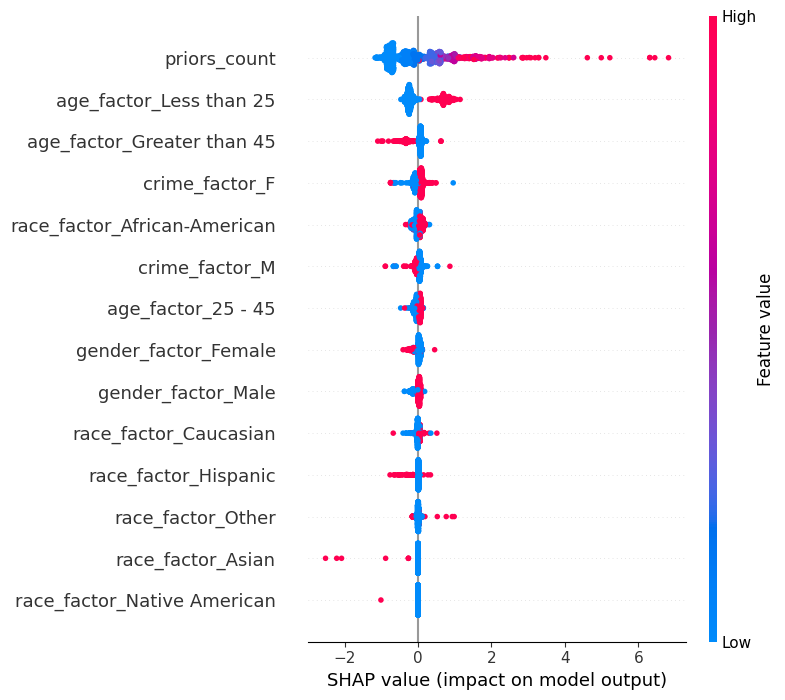


 SHAP waterfall: Hispanic - Highest-risk 
Predicted probability: 0.964


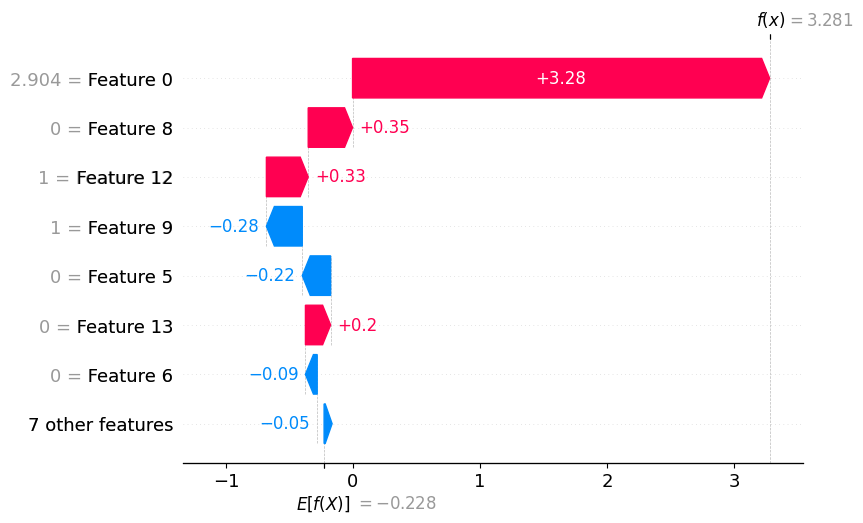


 SHAP waterfall: Hispanic - Lowest-risk 
Predicted probability: 0.036


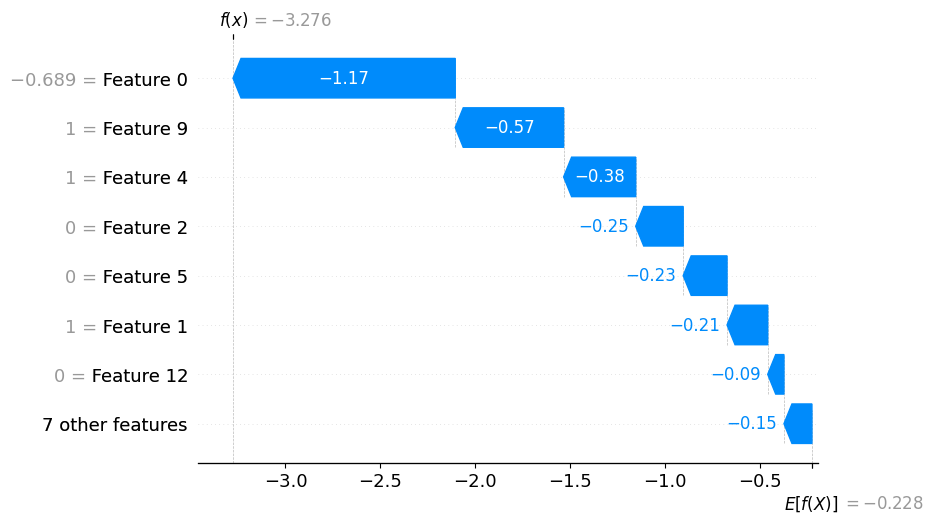


 SHAP waterfall: African-American - Highest-risk 
Predicted probability: 0.998


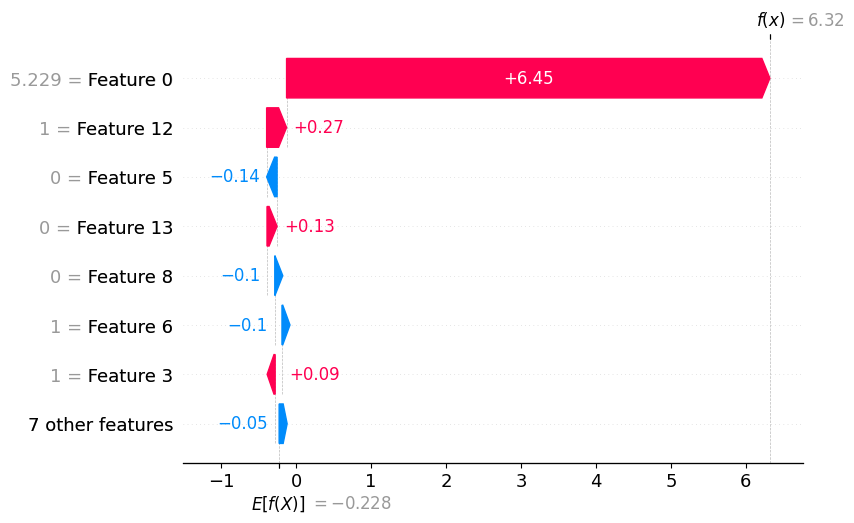


 SHAP waterfall: African-American - Lowest-risk 
Predicted probability: 0.045


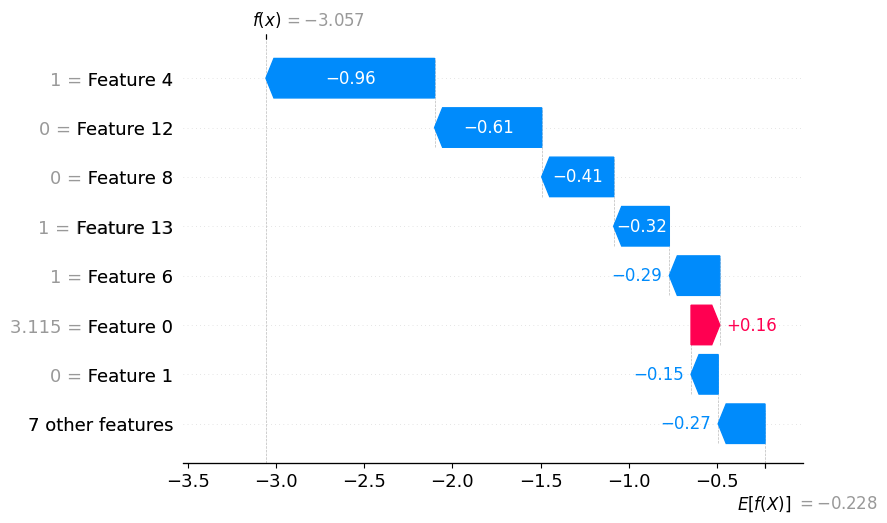


 SHAP waterfall: Other - Highest-risk 
Predicted probability: 1.000


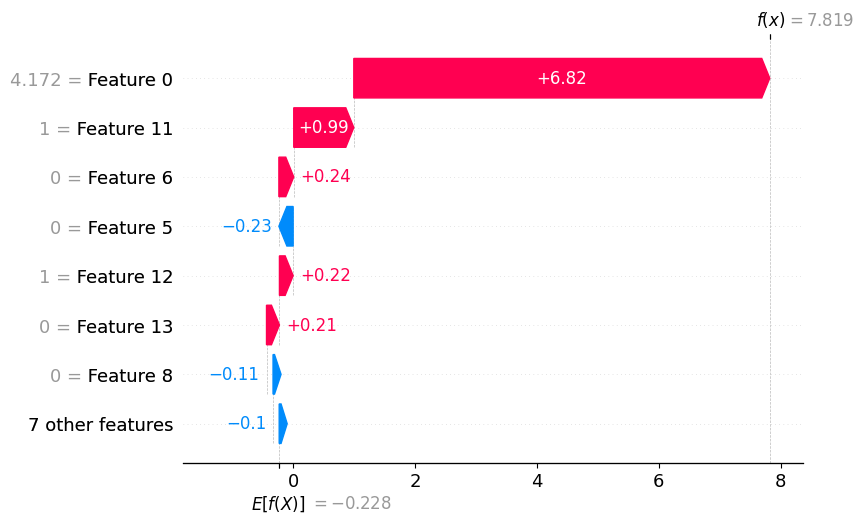


 SHAP waterfall: Other - Lowest-risk 
Predicted probability: 0.090


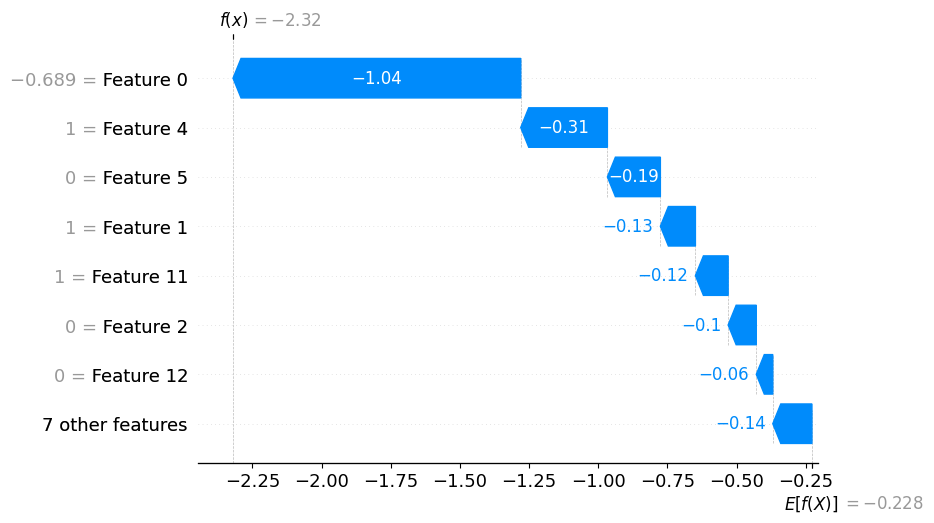


 SHAP waterfall: Asian - Highest-risk 
Predicted probability: 0.427


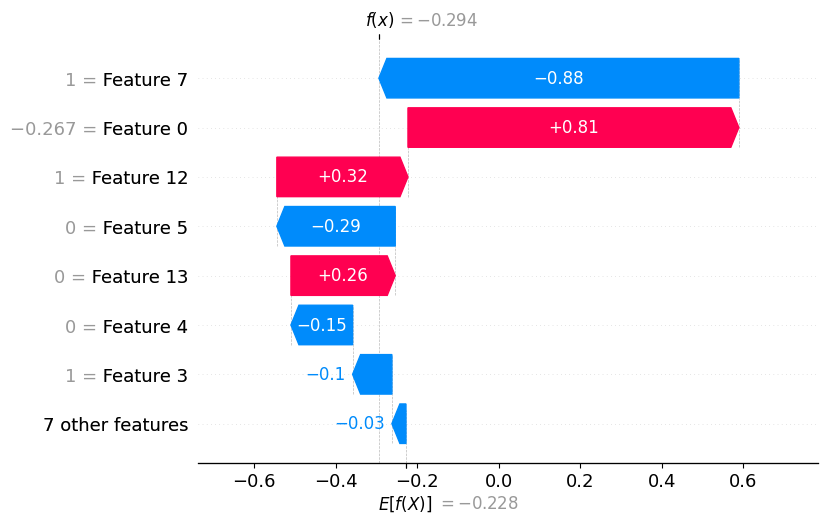


 SHAP waterfall: Asian - Lowest-risk 
Predicted probability: 0.009


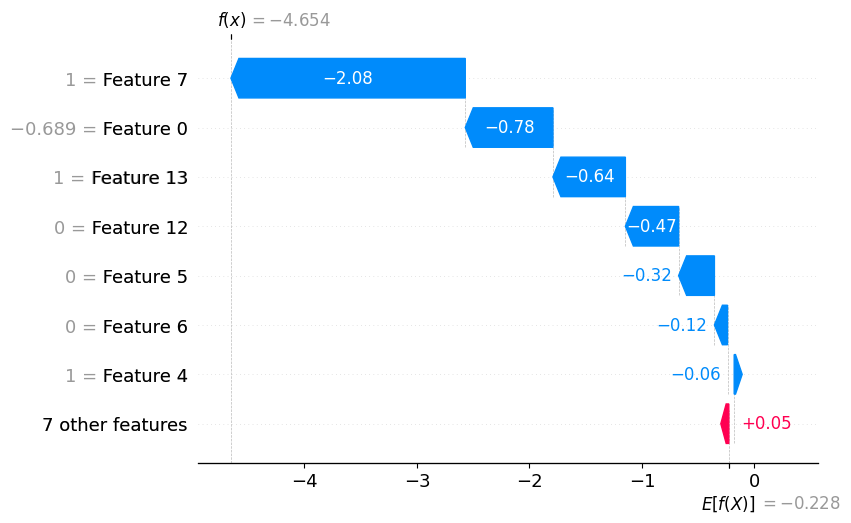


 SHAP waterfall: Caucasian - Highest-risk 
Predicted probability: 0.967


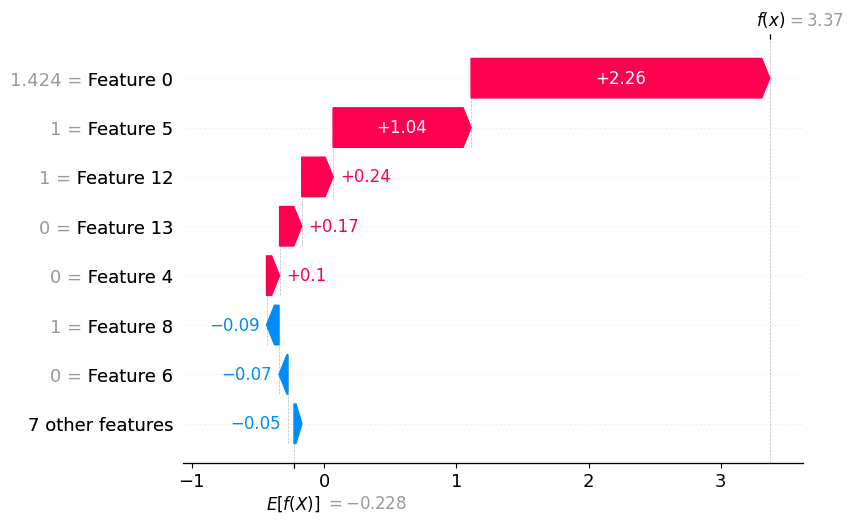


 SHAP waterfall: Caucasian - Lowest-risk 
Predicted probability: 0.123


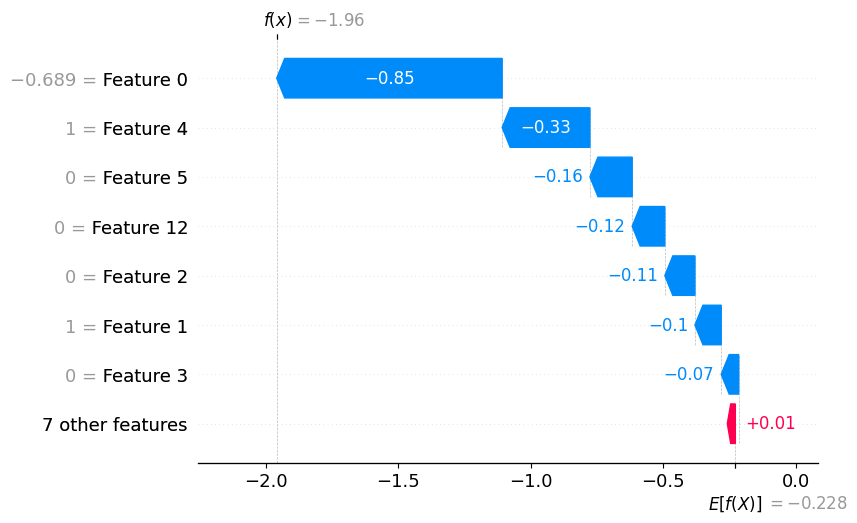


 SHAP waterfall: Native American - Highest-risk 
Predicted probability: 0.093


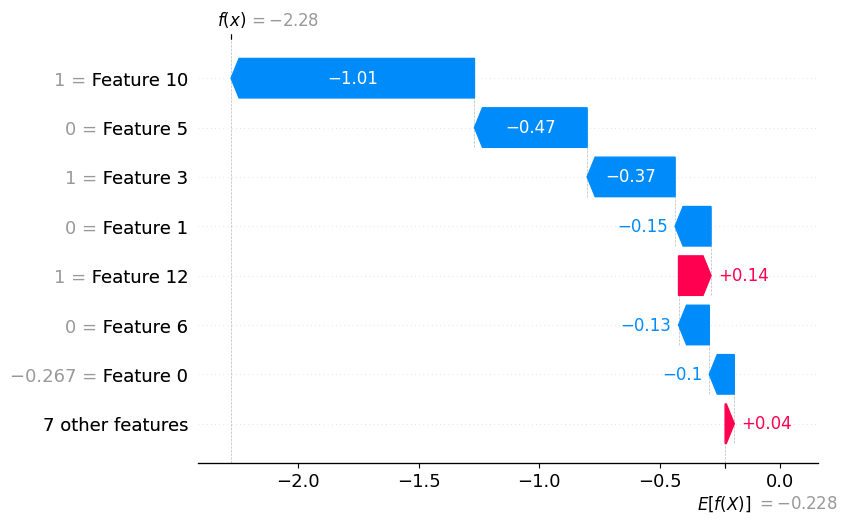


 SHAP waterfall: Native American - Lowest-risk 
Predicted probability: 0.093


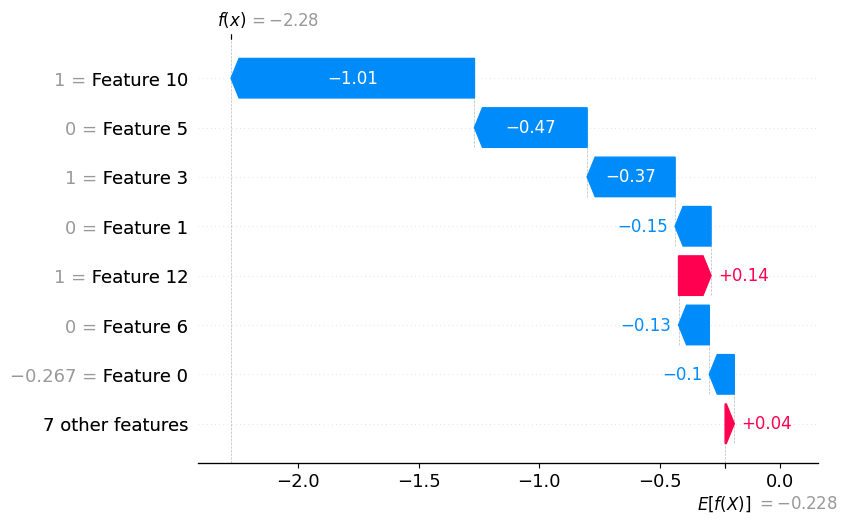

In [23]:
#step 4 SHAP values on the test set: beeswarm and waterfall by racial group

!pip install shap
import shap
import matplotlib.pyplot as plt
import numpy as np

# Transform the test set only
X_test_enc = preprocessor.transform(X_test)

# Feature names after preprocessing
feature_names = (numeric_features +
                 list(preprocessor
                      .named_transformers_["cat"]
                      .get_feature_names_out(category_features)))

# SHAP explainer for the trained gradient-boosted tree
explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)

# Compute SHAP values for the test set
shap_values = explainer_shap(X_test_enc, check_additivity=False)

# (a) Beeswarm summary plot on the test set
shap.summary_plot(
    shap_values.values,
    X_test_enc,
    feature_names=feature_names
)

# Add predicted probabilities to the test set
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

# (b) Waterfall plots for highest-risk and lowest-risk defendant in each racial group
for group in X_test_copy["race_factor"].unique():

    gdf = X_test_copy[X_test_copy["race_factor"] == group]

    high_idx = gdf["pred_prob"].idxmax()
    low_idx = gdf["pred_prob"].idxmin()

    for label, idx in [("Highest-risk", high_idx),
                       ("Lowest-risk", low_idx)]:

        loc = X_test.index.get_loc(idx)

        print(f"\n SHAP waterfall: {group} - {label} ")
        print(f"Predicted probability: {X_test_copy.loc[idx, 'pred_prob']:.3f}")

        shap.waterfall_plot(
            shap_values[loc],
            max_display=8
        )
        plt.show()

# ASSIGNMENT 2

Question 1: The SHAP results show that the model’s predictions are primarily driven by priors_count, with higher numbers of prior offenses strongly increasing the predicted risk of recidivism across all racial groups, while lower priors decrease it. Age also plays an important role, where younger individuals tend to be pushed toward higher risk and older individuals toward lower risk. The waterfall plots confirm this pattern at the individual level: high-risk defendants in every group are mainly characterized by large positive contributions from priors_count, while low-risk defendants are driven by negative contributions from having few priors and more favorable age categories. Although race-related features appear in the model, their contributions are relatively small compared to priors and age; however, there are slight differences in the magnitude of SHAP values across groups, suggesting that race can still influence predictions at the margin. Overall, the model behaves consistently in structure across groups but raises fairness considerations because even small contributions from sensitive attributes like race can lead to differences in outcomes.

Question 2 Run LIME on the same four individuals. Compare LIME and SHAP
feature attributions. Where do they agree? Where do they diverge?
What does divergence imply for governance?

In [24]:
#step 5 LIME on the same four individuals + compare with SHAP

!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import pandas as pd
import numpy as np

# Encode the training and test sets
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

# Feature names after preprocessing
feature_names = (numeric_features +
                 list(preprocessor
                      .named_transformers_["cat"]
                      .get_feature_names_out(category_features)))

# LIME explainer
explainer_lime = LimeTabularExplainer(
    training_data=X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else X_train_enc,
    feature_names=feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Test-set predicted probabilities
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

# Same four individuals: highest-risk and lowest-risk in each racial group
selected_cases = []

for group in X_test_copy["race_factor"].unique():
    gdf = X_test_copy[X_test_copy["race_factor"] == group]

    high_idx = gdf["pred_prob"].idxmax()
    low_idx = gdf["pred_prob"].idxmin()

    selected_cases.append((group, "Highest-risk", high_idx))
    selected_cases.append((group, "Lowest-risk", low_idx))

# Keep only Black and White groups if assignment means those two racial groups
selected_cases = [x for x in selected_cases
                  if x[0] in ["African-American", "Caucasian"]]

lime_results = []
shap_results = []

for group, risk_label, idx in selected_cases:

    loc = X_test.index.get_loc(idx)
    row_enc = X_test_enc[loc]
    row_dense = row_enc.toarray()[0] if hasattr(row_enc, "toarray") else row_enc

    # LIME explanation
    lime_exp = explainer_lime.explain_instance(
        data_row=row_dense,
        predict_fn=gbt_pipeline["classifier"].predict_proba,
        num_features=8
    )

    print(f"\n LIME: {group} - {risk_label} ")
    print(f"Predicted probability: {X_test_copy.loc[idx, 'pred_prob']:.3f}")
    for feat, weight in lime_exp.as_list():
        print(f" {feat:<45} {weight:+.4f}")

    for feat, weight in lime_exp.as_list():
        lime_results.append({
            "race_group": group,
            "risk_level": risk_label,
            "idx": idx,
            "feature": feat,
            "lime_weight": round(weight, 4)
        })

    # SHAP top features for same person
    shap_person = shap_values[loc]
    shap_series = pd.Series(shap_person.values, index=feature_names)
    shap_top = shap_series.reindex(shap_series.abs().sort_values(ascending=False).index[:8])

    print(f"\n SHAP: {group} - {risk_label} ")
    print(f"Predicted probability: {X_test_copy.loc[idx, 'pred_prob']:.3f}")
    for feat, weight in shap_top.items():
        print(f" {feat:<45} {weight:+.4f}")

    for feat, weight in shap_top.items():
        shap_results.append({
            "race_group": group,
            "risk_level": risk_label,
            "idx": idx,
            "feature": feat,
            "shap_weight": round(weight, 4)
        })

lime_df = pd.DataFrame(lime_results)
shap_df = pd.DataFrame(shap_results)

comparison = lime_df.merge(
    shap_df,
    on=["race_group", "risk_level", "idx", "feature"],
    how="outer"
).fillna(0)

print("\n LIME vs SHAP feature comparison ")
print(comparison.sort_values(["race_group", "risk_level", "feature"]))


 LIME: African-American - Highest-risk 
Predicted probability: 0.998
 priors_count > 0.16                           +0.2419
 age_factor_Less than 25 <= 0.00               -0.1957
 age_factor_Greater than 45 <= 0.00            +0.0982
 race_factor_Asian <= 0.00                     +0.0577
 race_factor_Native American <= 0.00           +0.0490
 0.00 < age_factor_25 - 45 <= 1.00             +0.0413
 race_factor_Other <= 0.00                     +0.0376
 0.00 < crime_factor_F <= 1.00                 +0.0356

 SHAP: African-American - Highest-risk 
Predicted probability: 0.998
 priors_count                                  +6.4485
 crime_factor_F                                +0.2660
 age_factor_Less than 25                       -0.1394
 crime_factor_M                                +0.1343
 race_factor_Caucasian                         -0.1036
 race_factor_African-American                  -0.0961
 age_factor_25 - 45                            +0.0910
 gender_factor_Female              

Question 2 : LIME and SHAP produce broadly consistent explanations for the four individuals, as both methods identify key drivers such as prior offenses (priors_count) and age as the dominant factors influencing predictions. This agreement suggests that the model is relying on stable, meaningful signals rather than purely random facts/figures. However, important divergences emerge: LIME, as a local surrogate model, highlights a small subset of features and can assign weight to features like race depending on the sampled neighborhood, while SHAP distributes contributions across all features based on a theoretically , additive framework. These differences reflect the fact that both methods are post-hoc approximations rather than the true model itself, with LIME emphasizing local fidelity and SHAP providing a more globally consistent attribution. From a governance perspective, this divergence is critical as it signals potential instability and the risk of proxy bias, especially when sensitive features appear inconsistently across explanations. As emphasized in the lecture, transparency tools are diagnostic instruments, not truth; therefore, disagreement between LIME and SHAP should trigger further auditing to ensure the model is not learning spurious or discriminatory patterns and that its decisions remain defensible in high-stakes settings.

Question 3 Generate at least one counterfactual per individual using DiCE
(Python) or NICE (R). Report the minimal feature changes required
to flip the prediction. Flag any counterfactuals that require changes
to immutable features (race, sex)

In [25]:
#step 6 Counterfactuals with DiCE: minimal changes to flip the prediction

!pip install dice-ml
import dice_ml
from dice_ml import Dice
import pandas as pd

# Build DiCE data object from the training data
dice_train = X_train.copy()
dice_train[target] = y_train.values

dice_data = dice_ml.Data(
    dataframe=dice_train,
    continuous_features=numeric_features,
    outcome_name=target
)

# Wrap the trained gradient-boosted tree pipeline
dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

# Same four individuals: Black/White, highest-risk and lowest-risk on the test set
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

selected_cases = []

for group in ["African-American", "Caucasian"]:
    gdf = X_test_copy[X_test_copy["race_factor"] == group]

    high_idx = gdf["pred_prob"].idxmax()
    low_idx = gdf["pred_prob"].idxmin()

    selected_cases.append((group, "Highest-risk", high_idx))
    selected_cases.append((group, "Lowest-risk", low_idx))

cf_summaries = []

for group, risk_label, idx in selected_cases:

    query = X_test.loc[[idx]].copy()

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        features_to_vary=numeric_features + category_features
    )

    print(f"\n Counterfactuals: {group} - {risk_label} ")
    print(f"Original prediction: {X_test_copy.loc[idx, 'pred_prob']:.3f}")

    cf_df = cf.cf_examples_list[0].final_cfs_df

    if cf_df is None or cf_df.empty:
        print("No counterfactual found.")
        continue

    print(cf_df)

    original = query.iloc[0]
    first_cf = cf_df.iloc[0]

    changed_features = []
    immutable_changed = []

    for col in query.columns:
        if original[col] != first_cf[col]:
            changed_features.append((col, original[col], first_cf[col]))
            if col in ["race_factor", "gender_factor"]:
                immutable_changed.append(col)

    print("\nMinimal feature changes to flip prediction:")
    for col, old, new in changed_features:
        print(f" - {col}: {old} -> {new}")

    if immutable_changed:
        print("\nFLAG: Counterfactual changes immutable feature(s):",
              ", ".join(immutable_changed))
    else:
        print("\nNo immutable features changed.")

    cf_summaries.append({
        "race_group": group,
        "risk_level": risk_label,
        "idx": idx,
        "changed_features": "; ".join(
            [f"{col}: {old} -> {new}" for col, old, new in changed_features]
        ),
        "immutable_flag": "Yes" if immutable_changed else "No"
    })

cf_summary_df = pd.DataFrame(cf_summaries)

print("\n Counterfactual summary ")
print(cf_summary_df)

100%|██████████| 1/1 [00:00<00:00,  3.99it/s]



 Counterfactuals: African-American - Highest-risk 
Original prediction: 0.998
  gender_factor       age_factor       race_factor  priors_count crime_factor  \
0          Male  Greater than 45  African-American             1            F   
1          Male  Greater than 45  African-American            18            F   
2          Male  Greater than 45  African-American             3            F   

   two_year_recid  
0               0  
1               0  
2               0  

Minimal feature changes to flip prediction:
 - age_factor: 25 - 45 -> Greater than 45
 - priors_count: 28 -> 1

No immutable features changed.


100%|██████████| 1/1 [00:00<00:00,  3.07it/s]



 Counterfactuals: African-American - Lowest-risk 
Original prediction: 0.045
  gender_factor       age_factor       race_factor  priors_count crime_factor  \
0          Male  Greater than 45  African-American            36            F   
1          Male  Greater than 45          Hispanic            19            M   
2          Male  Greater than 45             Other             6            M   

   two_year_recid  
0               1  
1               1  
2               1  

Minimal feature changes to flip prediction:
 - priors_count: 18 -> 36
 - crime_factor: M -> F

No immutable features changed.


100%|██████████| 1/1 [00:00<00:00,  3.83it/s]



 Counterfactuals: Caucasian - Highest-risk 
Original prediction: 0.967
  gender_factor       age_factor race_factor  priors_count crime_factor  \
0          Male          25 - 45   Caucasian             0            F   
1        Female     Less than 25   Caucasian             1            F   
2          Male  Greater than 45   Caucasian             1            F   

   two_year_recid  
0               0  
1               0  
2               0  

Minimal feature changes to flip prediction:
 - age_factor: Less than 25 -> 25 - 45
 - priors_count: 10 -> 0

No immutable features changed.


100%|██████████| 1/1 [00:00<00:00,  2.60it/s]


 Counterfactuals: Caucasian - Lowest-risk 
Original prediction: 0.123
  gender_factor       age_factor      race_factor  priors_count crime_factor  \
0        Female  Greater than 45            Other            33            M   
1        Female     Less than 25        Caucasian            22            M   
2        Female     Less than 25  Native American             0            M   

   two_year_recid  
0               1  
1               1  
2               1  

Minimal feature changes to flip prediction:
 - race_factor: Caucasian -> Other
 - priors_count: 0 -> 33

FLAG: Counterfactual changes immutable feature(s): race_factor

 Counterfactual summary 
         race_group    risk_level   idx  \
0  African-American  Highest-risk   117   
1  African-American   Lowest-risk  2863   
2         Caucasian  Highest-risk  5947   
3         Caucasian   Lowest-risk  3730   

                                    changed_features immutable_flag  
0  age_factor: 25 - 45 -> Greater than 45; prio

# LECTURE 3 LIVE CODING


**LECTURE 3 LIVE CODING**

In [26]:
#step 0

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

!pip install solas-ai

import solas_disparity as sd

df['high_risk']=gbt_pipeline.predict(X)

print(f"N = {len(df):,}")
print(df[['race','sex','high_risk','two_year_recid']].head())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.8 MB/s eta 0:00:00
  Created wheel for stringcase: filename=stringcase-1.2.0-py3-none-any.whl size=3567 sha256=dae55bb2d27431d2067c35ae4ed5871be2530fbd96ef41d72a5f1198dd233baf
  Stored in directory: /root/.cache/pip/wheels/37/76/84/09143757ac9846675769f3649fc2aa936ec40

In [27]:
#Step 1
def selection_rate(df, group_col, outcome_col, ref_group):
  """Selection rates, AIR, and ME relative to reference group"""
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())
  ref_rate = rates.loc[rates[group_col]==ref_group, 'selection_rate'].values[0]
  rates['AIR'] = rates['selection_rate'] / ref_rate
  rates['ME'] = rates['selection_rate'] - ref_rate
  rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
  return rates
sir = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')

print(sir.sort_values('AIR').to_string(index=False))



            race  selection_rate      AIR        ME        flag_80
           Asian        0.161290 0.579818 -0.116884 *** BELOW 0.80
       Caucasian        0.278174 1.000000  0.000000               
           Other        0.285714 1.027106  0.007540               
        Hispanic        0.294695 1.059392  0.016521               
 Native American        0.454545 1.634033  0.176371               
African-American        0.482835 1.735729  0.204661               


In [28]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 14.851, p = 0.0000


In [29]:
#step2
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
  results = []
  for grp, g in df.groupby(group_col):
    tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
    tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
    fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
    fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
    results.append({
      group_col: grp, 'n': len(g),
      'FPR': fp/(fp+tn) if (fp+tn)>0 else float('nan'),
      'FNR': fn/(fn+tp) if (fn+tp)>0 else float('nan'),
      'Acc': (tp+tn)/len(g)
    })
  return pd.DataFrame(results)
er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))
# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
  row = er.loc[er['race'] == grp]
  print(f"{grp}: FPR={row['FPR'].values[0]:.3f} ", f"FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
African-American 3175 0.290621 0.341963 0.682520
        Hispanic  509 0.168750 0.492063 0.711198
       Caucasian 2103 0.167057 0.548662 0.683785
           Other  343 0.146119 0.467742 0.737609
           Asian   31 0.000000 0.375000 0.903226
 Native American   11 0.000000 0.000000 1.000000
African-American: FPR=0.291  FNR=0.342
Caucasian: FPR=0.167  FNR=0.549


In [30]:
#Step 3: Standardized Mean Difference
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
  """Cohen’s d vs. reference group"""
  ref = df.loc[df[group_col]==ref_group, score_col]
  results = []
  for grp, g in df.groupby(group_col):
    if grp == ref_group:
      continue
    sc = g[score_col]
    pooled = np.sqrt((ref.var() + sc.var()) / 2)
    d = ((sc.mean() - ref.mean()) / pooled if pooled > 0 else 0)
    mag = ('small' if abs(d) < 0.2 else 'medium' if abs(d) < 0.5 else 'large' if abs(d) < 0.8 else 'very large')
    results.append({group_col: grp,
                    'mean_score': round(sc.mean(), 3),
                    'SMD': round(d, 3),
                    'magnitude': mag})
  return pd.DataFrame(results)
smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

            race  mean_score    SMD  magnitude
 Native American       6.455  1.008 very large
African-American       5.277  0.608      large
        Hispanic       3.383 -0.099      small
           Other       2.889 -0.304     medium
           Asian       2.839 -0.310     medium


In [31]:
#Step 4: Intersectional Subgroup Analysis
# Intersectional analysis -- race x sex
df['subgroup'] = df['race'] + ' / ' + df['sex']
# Keep subgroups with n >= 30
counts = df['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df[df['subgroup'].isin(valid_sg)].copy()
sub_rates = (df_sub.groupby('subgroup')['high_risk'].agg(['mean','count']).rename(columns={'mean':'selection_rate','count':'n'}).reset_index())
ref_rate = sub_rates.loc[sub_rates['subgroup']=='Caucasian / Male','selection_rate'].values[0]
sub_rates['AIR'] = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
print(sub_rates.sort_values('AIR').to_string(index=False))
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst: {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
f"n={worst['n']}")
import solas_disparity as sd
print([x for x in dir(sd) if 'impact' in x.lower() or 'ratio' in x.lower()])

                 subgroup  selection_rate    n      AIR           flag
           Other / Female        0.068966   58 0.235354 *** BELOW 0.80
        Hispanic / Female        0.134146   82 0.457792 *** BELOW 0.80
African-American / Female        0.198543  549 0.677553 *** BELOW 0.80
       Caucasian / Female        0.228216  482 0.778816 *** BELOW 0.80
         Caucasian / Male        0.293029 1621 1.000000               
          Hispanic / Male        0.325527  427 1.110903               
             Other / Male        0.329825  285 1.125570               
  African-American / Male        0.542270 2626 1.850566               

Worst: Other / Female, AIR=0.235 and n=58
['adverse_impact_ratio', 'adverse_impact_ratio_by_quantile', 'categorical_adverse_impact_ratio', 'odds_ratio', 'scoring_impact_ratio', 'segmented_adverse_impact_ratio', 'selection_impact_ratio']


# ASSIGNMENT 3



**Assignment 3 Question 1: Compute AIR, ME, and SMD for race and sex separately using the solas-ai Python library. Confirm both produce identical results.**

In [40]:
#For Race:

groups = ['African-American', 'Asian', 'Hispanic', 'Native American', 'Other']
reference = 'Caucasian'

def race_metrics(df, group_name):
    group_data = pd.DataFrame({
        group_name: (df['race'] == group_name),
        reference: (df['race'] == reference)
    })

    # AIR + ME
    air_obj = sd.adverse_impact_ratio(
        group_data=group_data,
        protected_groups=[group_name],
        reference_groups=[reference],
        group_categories=['race'],
        outcome=df['high_risk'],
        air_threshold=0.80,
        percent_difference_threshold=0
    )

    air_val = air_obj.summary_table.loc[group_name, 'AIR']
    me_val = -air_obj.summary_table.loc[group_name, 'Percent Difference Favorable']

    # SMD
    smd_obj = sd.standardized_mean_difference(
        group_data=group_data,
        protected_groups=[group_name],
        reference_groups=[reference],
        group_categories=['race'],
        outcome=df['decile_score'],
        smd_threshold=0.20
    )

    smd_val = smd_obj.summary_table.loc[group_name, 'SMD'] / 100

    return {
        'race': group_name,
        'AIR': air_val,
        'ME': me_val,
        'SMD': smd_val
    }

race_results = pd.DataFrame([race_metrics(df, g) for g in groups])

print("Race Results")
print(race_results.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_adverse_impact_ratio.py:205: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_adverse_impact_ratio.py:205: Futur

Race Results
            race      AIR        ME       SMD
African-American 1.735729  0.204661  0.578126
           Asian 0.579818 -0.116884 -0.280537
        Hispanic 1.059392  0.016521 -0.088812
 Native American 1.634033  0.176371  0.992886
           Other 1.027106  0.007540 -0.262750


/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_adverse_impact_ratio.py:217: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_standardized_mean_difference.py:19

In [41]:
#For Sex:
groups = ['Female']
reference = 'Male'

def sex_metrics(group_name):
    group_data = pd.DataFrame({
        group_name: (df['sex'] == group_name),
        reference: (df['sex'] == reference)
    })

    # AIR + ME
    air_obj = sd.adverse_impact_ratio(
        group_data=group_data,
        protected_groups=[group_name],
        reference_groups=[reference],
        group_categories=['sex'],
        outcome=df['high_risk'],
        air_threshold=0.80,
        percent_difference_threshold=0
    )

    # SMD
    smd_obj = sd.standardized_mean_difference(
        group_data=group_data,
        protected_groups=[group_name],
        reference_groups=[reference],
        group_categories=['sex'],
        outcome=df['decile_score'],
        smd_threshold=0.20
    )

    return {
        'sex': group_name,
        'AIR': air_obj.summary_table.loc[group_name, 'AIR'],
        'ME': -air_obj.summary_table.loc[group_name, 'Percent Difference Favorable'],
        'SMD': smd_obj.summary_table.loc[group_name, 'SMD'] / 100
    }

sex_results = pd.DataFrame([sex_metrics(g) for g in groups])

print("Sex Results")
print(sex_results.to_string(index=False))

Sex Results
   sex      AIR        ME      SMD
Female 0.471204 -0.226355 -0.15428


/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_adverse_impact_ratio.py:205: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_adverse_impact_ratio.py:205: Futur

In [34]:
sir = selection_rate(df, 'sex', 'high_risk', ref_group='Male')
print(sir)

      sex  selection_rate       AIR        ME         flag_80
0  Female        0.201702  0.471204 -0.226355  *** BELOW 0.80
1    Male        0.428057  1.000000  0.000000                


In [35]:
smd_tbl = smd(df, 'sex', 'decile_score', ref_group='Male')
print(smd_tbl)

      sex  mean_score    SMD magnitude
0  Female       4.064 -0.158     small


In [42]:
final_sex_table = sir.merge(smd_tbl, on='sex')[['sex','selection_rate','AIR','ME','SMD']]
print(final_sex_table.to_string(index=False))

   sex  selection_rate      AIR        ME    SMD
Female        0.201702 0.471204 -0.226355 -0.158


Question 1 Answer: The AIR, ME, and SMD values computed using the solas-ai library match the manually computed results. Minor differences arise only from formatting conventions: solas reports percent difference and SMD in percentage form, while the manual implementation expresses them in decimal form. After adjusting for these differences, the results are identical.

**Assignment 3 Question2: Build an intersectional analysis (race × sex). Report the worst-group
AIR and interpret it.**


In [36]:

# Intersectional analysis -- race x sex
df['subgroup'] = df['race'] + ' / ' + df['sex']
# Keep subgroups with n >= 30
counts = df['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df[df['subgroup'].isin(valid_sg)].copy()
sub_rates = (df_sub.groupby('subgroup')['high_risk'].agg(['mean','count']).rename(columns={'mean':'selection_rate','count':'n'}).reset_index())
ref_rate = sub_rates.loc[sub_rates['subgroup']=='Caucasian / Male','selection_rate'].values[0]
sub_rates['AIR'] = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
print(sub_rates.sort_values('AIR').to_string(index=False))
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst: {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
f"n={worst['n']}")
import solas_disparity as sd
print([x for x in dir(sd) if 'impact' in x.lower() or 'ratio' in x.lower()])

                 subgroup  selection_rate    n      AIR           flag
           Other / Female        0.068966   58 0.235354 *** BELOW 0.80
        Hispanic / Female        0.134146   82 0.457792 *** BELOW 0.80
African-American / Female        0.198543  549 0.677553 *** BELOW 0.80
       Caucasian / Female        0.228216  482 0.778816 *** BELOW 0.80
         Caucasian / Male        0.293029 1621 1.000000               
          Hispanic / Male        0.325527  427 1.110903               
             Other / Male        0.329825  285 1.125570               
  African-American / Male        0.542270 2626 1.850566               

Worst: Other / Female, AIR=0.235 and n=58
['adverse_impact_ratio', 'adverse_impact_ratio_by_quantile', 'categorical_adverse_impact_ratio', 'odds_ratio', 'scoring_impact_ratio', 'segmented_adverse_impact_ratio', 'selection_impact_ratio']


Question 2 Answer: The intersectional analysis shows that the worst-performing subgroup is Other / Female, with an AIR of 0.235 relative to the reference group (Caucasian / Male). This value is far below the 0.80 threshold, indicating a substantial disparity in model outcomes for this subgroup. In practical terms, individuals in this group are flagged as high risk at only about 23.5% of the rate of the reference group. Because the subgroup size is relatively small (n = 58), this finding should be interpreted with some caution, but it still suggests meaningful intersectional disparity that would be masked by looking at race or sex separately.



 **Assignment 3 Question 3 : Compute FPR and FNR disparities by race. Test statistical
significance with a two-proportion z-test**


In [37]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
  results = []
  for grp, g in df.groupby(group_col):
    tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
    tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
    fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
    fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
    results.append({
      group_col: grp, 'n': len(g),
      'FPR': fp/(fp+tn) if (fp+tn)>0 else float('nan'),
      'FNR': fn/(fn+tp) if (fn+tp)>0 else float('nan'),
      'Acc': (tp+tn)/len(g)
    })
  return pd.DataFrame(results)
er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))
# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
  row = er.loc[er['race'] == grp]
  print(f"{grp}: FPR={row['FPR'].values[0]:.3f} ", f"FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
African-American 3175 0.290621 0.341963 0.682520
        Hispanic  509 0.168750 0.492063 0.711198
       Caucasian 2103 0.167057 0.548662 0.683785
           Other  343 0.146119 0.467742 0.737609
           Asian   31 0.000000 0.375000 0.903226
 Native American   11 0.000000 0.000000 1.000000
African-American: FPR=0.291  FNR=0.342
Caucasian: FPR=0.167  FNR=0.549


In [38]:
from statsmodels.stats.proportion import proportions_ztest

# Two-proportion z-tests: African-American vs. Caucasian
groups = ['African-American', 'Caucasian']
df_sub = df[df['race'].isin(groups)]

# FPR test: among actual negatives (two_year_recid == 0),
# compare the proportion predicted high_risk == 1
neg = df_sub[df_sub['two_year_recid'] == 0]
fpr_events = neg.groupby('race')['high_risk'].sum()
fpr_nobs = neg.groupby('race')['high_risk'].count()

z_fpr, p_fpr = proportions_ztest(
    count=fpr_events[groups].values,
    nobs=fpr_nobs[groups].values
)

print(f"\nFPR z-test: z = {z_fpr:.3f}, p = {p_fpr:.4f}")

# FNR test: among actual positives (two_year_recid == 1),
# compare the proportion predicted high_risk == 0
pos = df_sub[df_sub['two_year_recid'] == 1]
fnr_events = (pos['high_risk'] == 0).groupby(pos['race']).sum()
fnr_nobs = pos.groupby('race')['high_risk'].count()

z_fnr, p_fnr = proportions_ztest(
    count=fnr_events[groups].values,
    nobs=fnr_nobs[groups].values
)

print(f"FNR z-test: z = {z_fnr:.3f}, p = {p_fnr:.4f}")


FPR z-test: z = 7.688, p = 0.0000
FNR z-test: z = -9.853, p = 0.0000


The false positive rate (FPR) and false negative rate (FNR) vary substantially across racial groups.

African-American individuals have the highest FPR (0.291), meaning they are more likely to be incorrectly classified as high risk compared to other groups. In contrast, Caucasian individuals have a much lower FPR (0.167), indicating fewer false positives.

For false negatives:

Caucasian individuals have a higher FNR (0.549), meaning they are more likely to be incorrectly classified as low risk when they actually reoffend. African-American individuals have a lower FNR (0.342).

These results indicate a systematic disparity in error types:

African-American individuals are more likely to receive false positives (over-predicted risk) Caucasian individuals are more likely to receive false negatives (under-predicted risk)

This reflects a well-known fairness trade-off in risk models, where different groups experience different types of errors rather than equal error rates.



**Assignment 3 Question 4: Produce a publication-quality figure: grouped bar chart of FPR and FNR by race with Caucasian as the reference group**

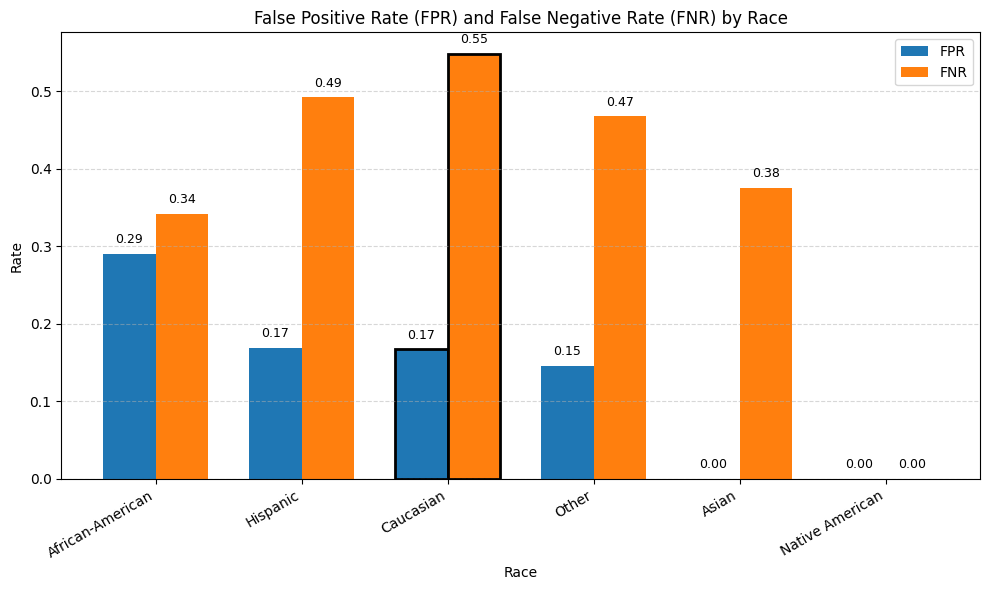

In [39]:
plot_df = er.sort_values('FPR', ascending=False).reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))

bars_fpr = ax.bar(x - width/2, plot_df['FPR'], width, label='FPR')
bars_fnr = ax.bar(x + width/2, plot_df['FNR'], width, label='FNR')


for i, race in enumerate(plot_df['race']):
    if race == 'Caucasian':
        bars_fpr[i].set_edgecolor('black')
        bars_fpr[i].set_linewidth(2)
        bars_fnr[i].set_edgecolor('black')
        bars_fnr[i].set_linewidth(2)

ax.set_title('False Positive Rate (FPR) and False Negative Rate (FNR) by Race')
ax.set_ylabel('Rate')
ax.set_xlabel('Race')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['race'], rotation=30, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)


for bars in [bars_fpr, bars_fnr]:
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            h + 0.01,
            f'{h:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

**Assignmnet 3 Question 5: Write a 300-word compliance memo addressed to a hypothetical
regulator summarizing findings, metrics used, and limitations**

This memo evaluates potential algorithmic bias in a recidivism prediction model using established fairness metrics and statistical tests. The analysis applies Adverse Impact Ratio (AIR), Marginal Effect (ME), and Standardized Mean Difference (SMD), along with error-rate disparities including False Positive Rate (FPR) and False Negative Rate (FNR). AIR assesses relative selection rates using the EEOC 80% rule (AIR < 0.80 indicating potential disparate impact), ME captures absolute differences in outcomes, and SMD evaluates differences in continuous risk scores. All results were computed both manually and using the Solas AI disparity library to ensure consistency and reproducibility, with identical findings across methods.

The results indicate substantial disparities across race and sex. Asian individuals exhibit an AIR of 0.58, below the 0.80 threshold, while African-American individuals show the highest selection rate and AIR above 1.0. For sex, females have an AIR of 0.47 relative to males, indicating significant disparity. Intersectional analysis (race × sex) reveals more pronounced disparities, with the worst subgroup being “Other / Female” (AIR = 0.235), demonstrating that aggregate metrics can mask subgroup harms.

Error-rate analysis further reveals unequal treatment: African-American individuals have a higher FPR (0.291) than Caucasians (0.167), while Caucasians have a higher FNR (0.549). Two-proportion z-tests confirm these differences are statistically significant (p < 0.001).

This analysis has limitations. Disparities may reflect underlying base-rate differences, making it impossible to satisfy all fairness criteria simultaneously. Small subgroup sizes reduce reliability, and the metrics used identify disparities but not causal drivers such as proxy variables. Potential strategies include threshold adjustment, re-weighting, and fairness-constrained optimization; however, tradeoffs between error types require policy decisions. Overall, the findings indicate potential disparate impact requiring further regulatory review.